In [1]:
import os
import sys
import gdstk
import numpy as np
import matplotlib.pyplot as plt

# Add current directory to path to import the generator
sys.path.append(os.getcwd())

from quantum_dot_pad_generator_18dot_v2 import QuantumDotPadGenerator18Dot
from quantum_dot_pad_generator_18dot_v3 import QuantumDotPadGenerator18DotV3

%matplotlib inline

In [2]:
# 1. Initialize the generator

generator = QuantumDotPadGenerator18DotV3()

# generator = QuantumDotPadGenerator18Dot()

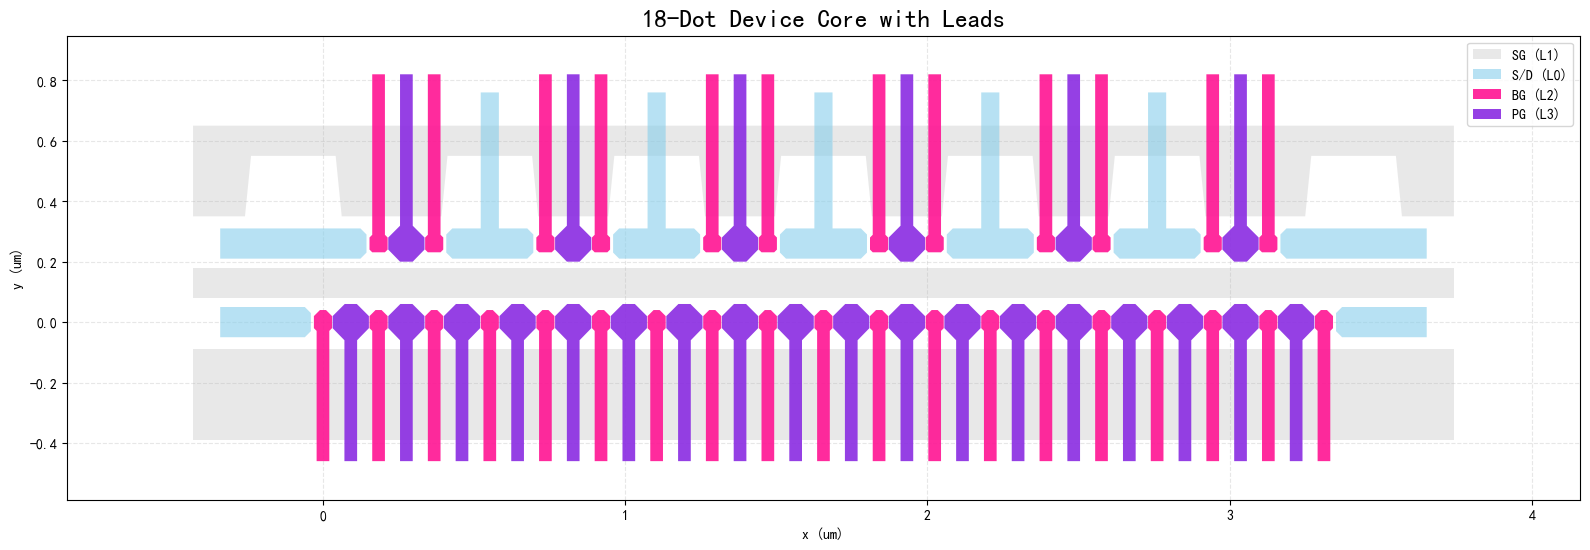

In [3]:


# 2. Generate the 18-dot device layout
device_lib, device_cell, device_connection_points = generator.generate_quantum_dot_layout(
    sg_extension = 0.4
)

# Visualize the device core
generator._plot_gds(device_cell, title="18-Dot Device Core with Leads")

--- 18-Dot Pad Frame with Four Active Regions ---
正在可视化: 18-Dot Pad Frame with Four Active Regions...


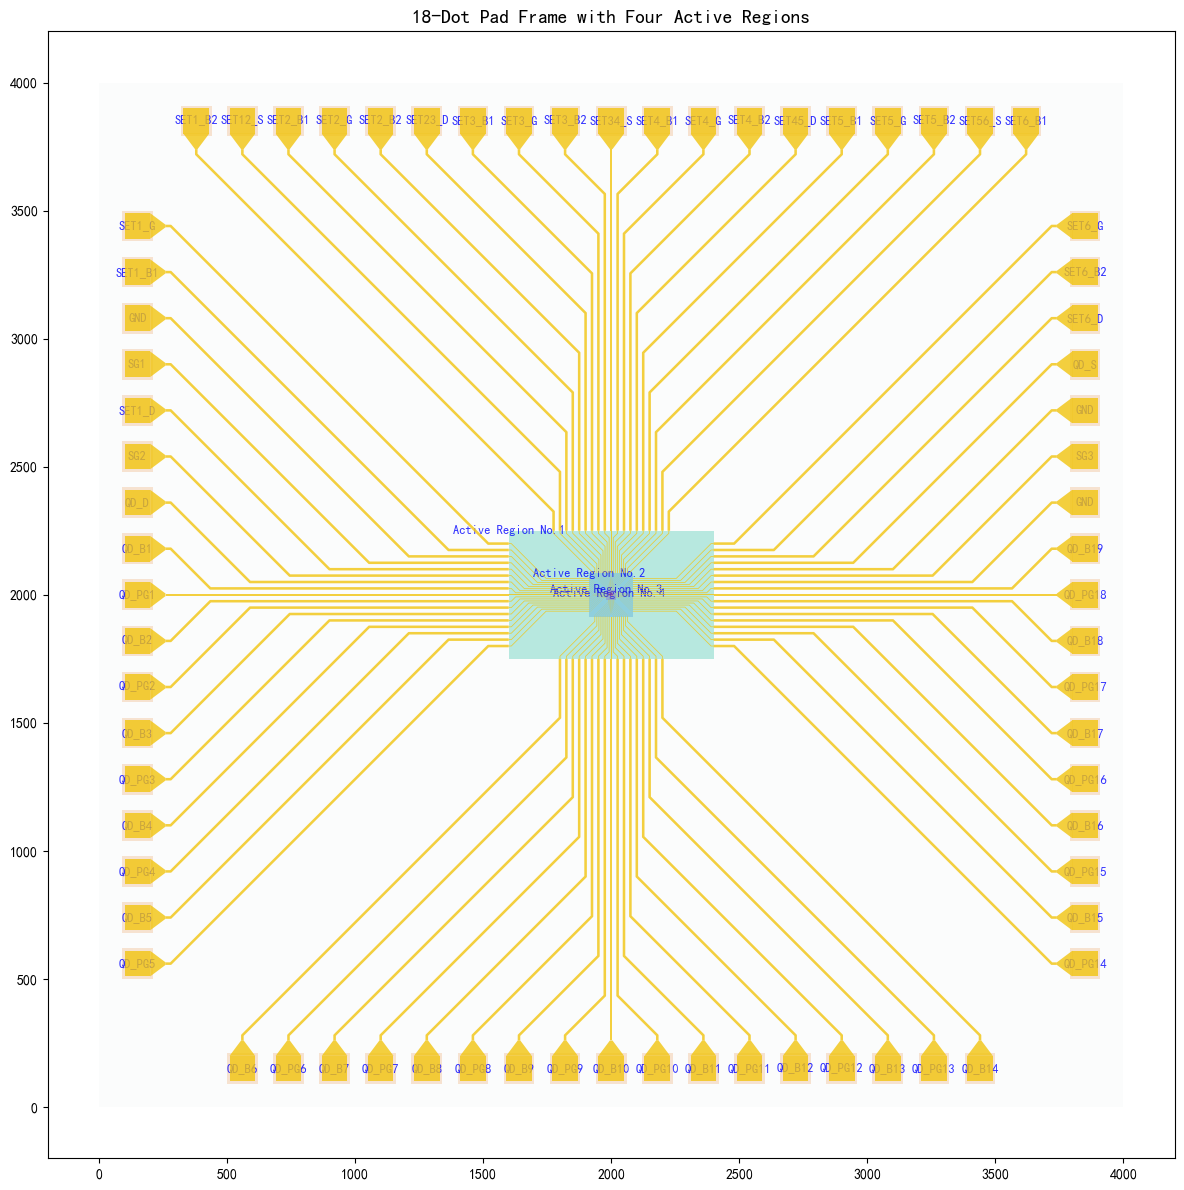

GDS 文件已保存到: '18dot_pad_frame_v2.gds'



In [11]:
# 3. Generate the pad frame layout with four active regions
pad_lib, pad_cell, pad_connection_points, active_center, all_pads_info = generator.generate_pad_frame_layout(
    layout_width=4000, 
    layout_height=4000, 
    taper_length=60,
    pad_spacing=80,

    # active_size=530,
    active_width=800,
    active_height=500,
    trace_width=10, 
    trace_spacing=15,

    active_size_2=170,
    inner_trace_width=3.0,
    inner_trace_spacing = 5.0,
    active_entry_len_2=15,

    active_size_3=40,
    inner_trace_width_3=0.5,
    inner_trace_spacing_3=1,
    active_entry_len_3=8,

    active_width_4=15, 
    active_height_4=12,
    inner_trace_width_4=0.1,
    inner_trace_spacing_4=0.2,
    active_entry_len_4=1
)

# Visualize and save the pad frame
generator.visualize_and_save_pad_frame(pad_lib, pad_cell, "18-Dot Pad Frame with Four Active Regions", "18dot_pad_frame_v2.gds")

--- 18-Dot Full Assembly v2 ---
正在可视化: 18-Dot Full Assembly v2...
GDS 文件已保存到: '18dot_full_assembly_v2.gds'


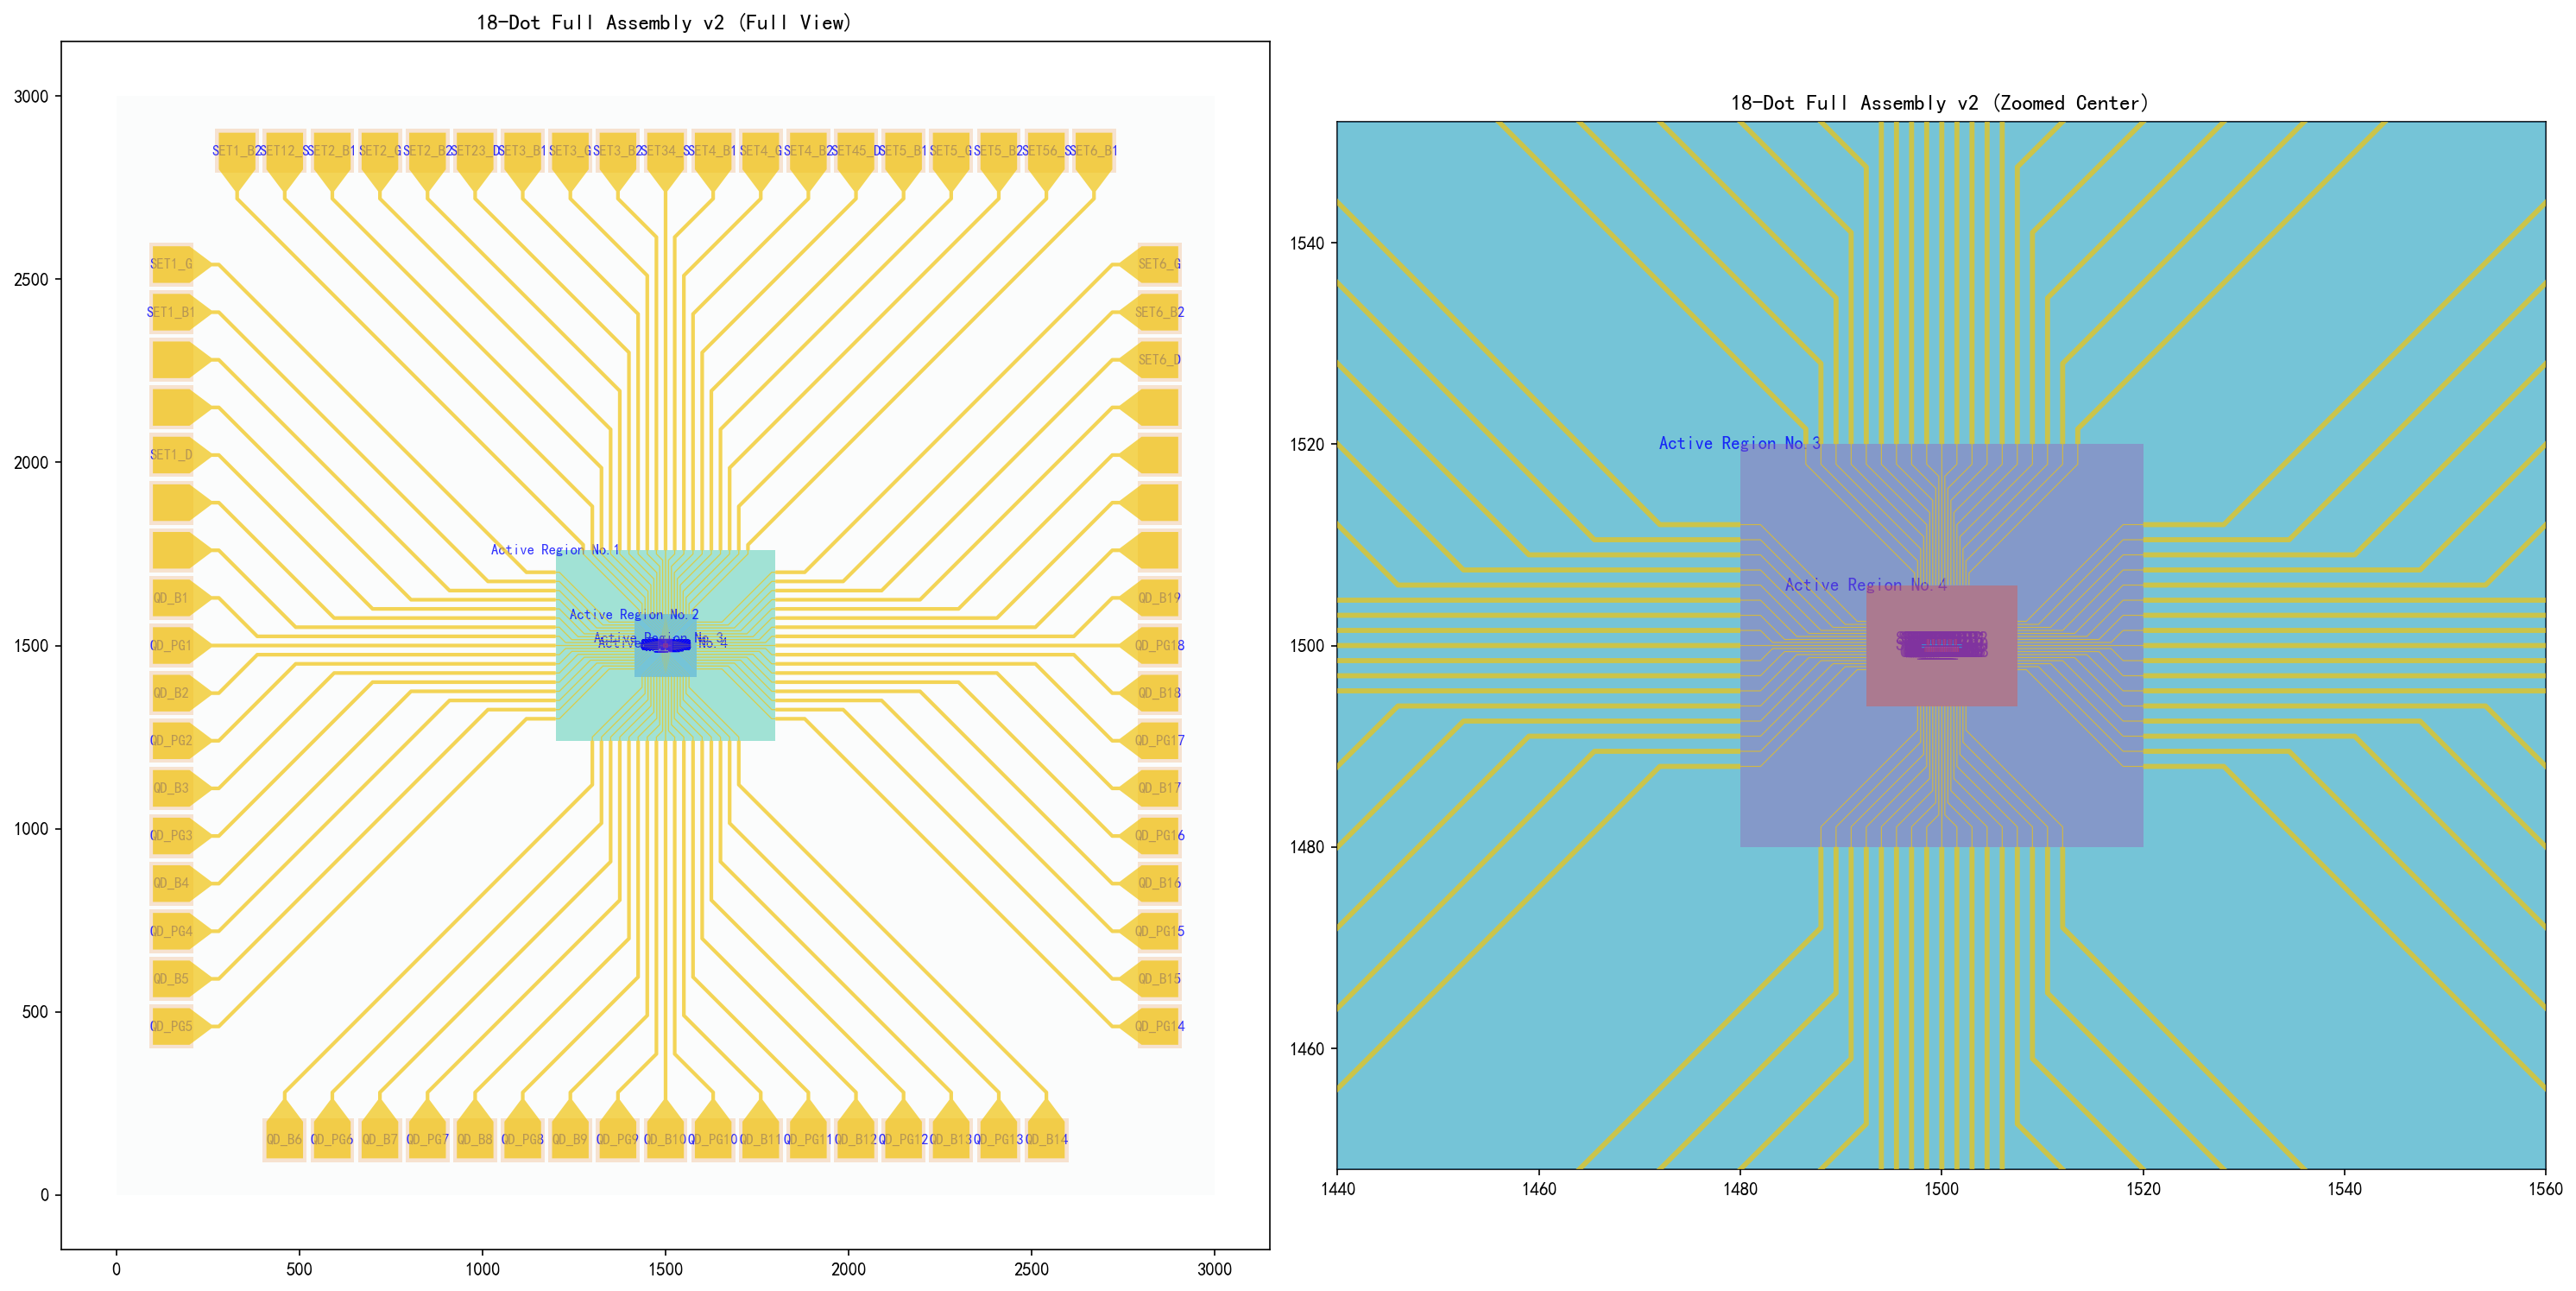

Successfully assembled and saved 18dot_full_assembly_v2.gds


In [21]:
# 4. Assemble the device and the pad frame
assembly_lib1, assembly_cell1 = generator.assemble_device_and_pad_frame()

if assembly_cell1 is not None:
    # Visualize and save the final assembly
    generator.visualize_and_save_assembly(assembly_lib1, assembly_cell1, "18-Dot Full Assembly v2", "18dot_full_assembly_v2.gds")
    print("Successfully assembled and saved 18dot_full_assembly_v2.gds")
else:
    print("Error: Assembly failed.")

Connecting bottom pad leads...
Connecting right pad leads...
Connecting left pad leads...
Connecting SG3 pad lead...
Connecting QD_S pad lead...
Connecting SET6_D pad lead...
Connecting left pad leads...
Connecting QD_D pad lead...
Connecting SG2 pad lead...
Connecting SET1_D pad lead...
Connecting SG1 pad lead...
Connecting top pad leads...
--- 18-Dot Full Assembly v2 with Wires ---
正在可视化: 18-Dot Full Assembly v2 with Wires...
GDS 文件已保存到: '18dot_full_assembly_v2_wired.gds'


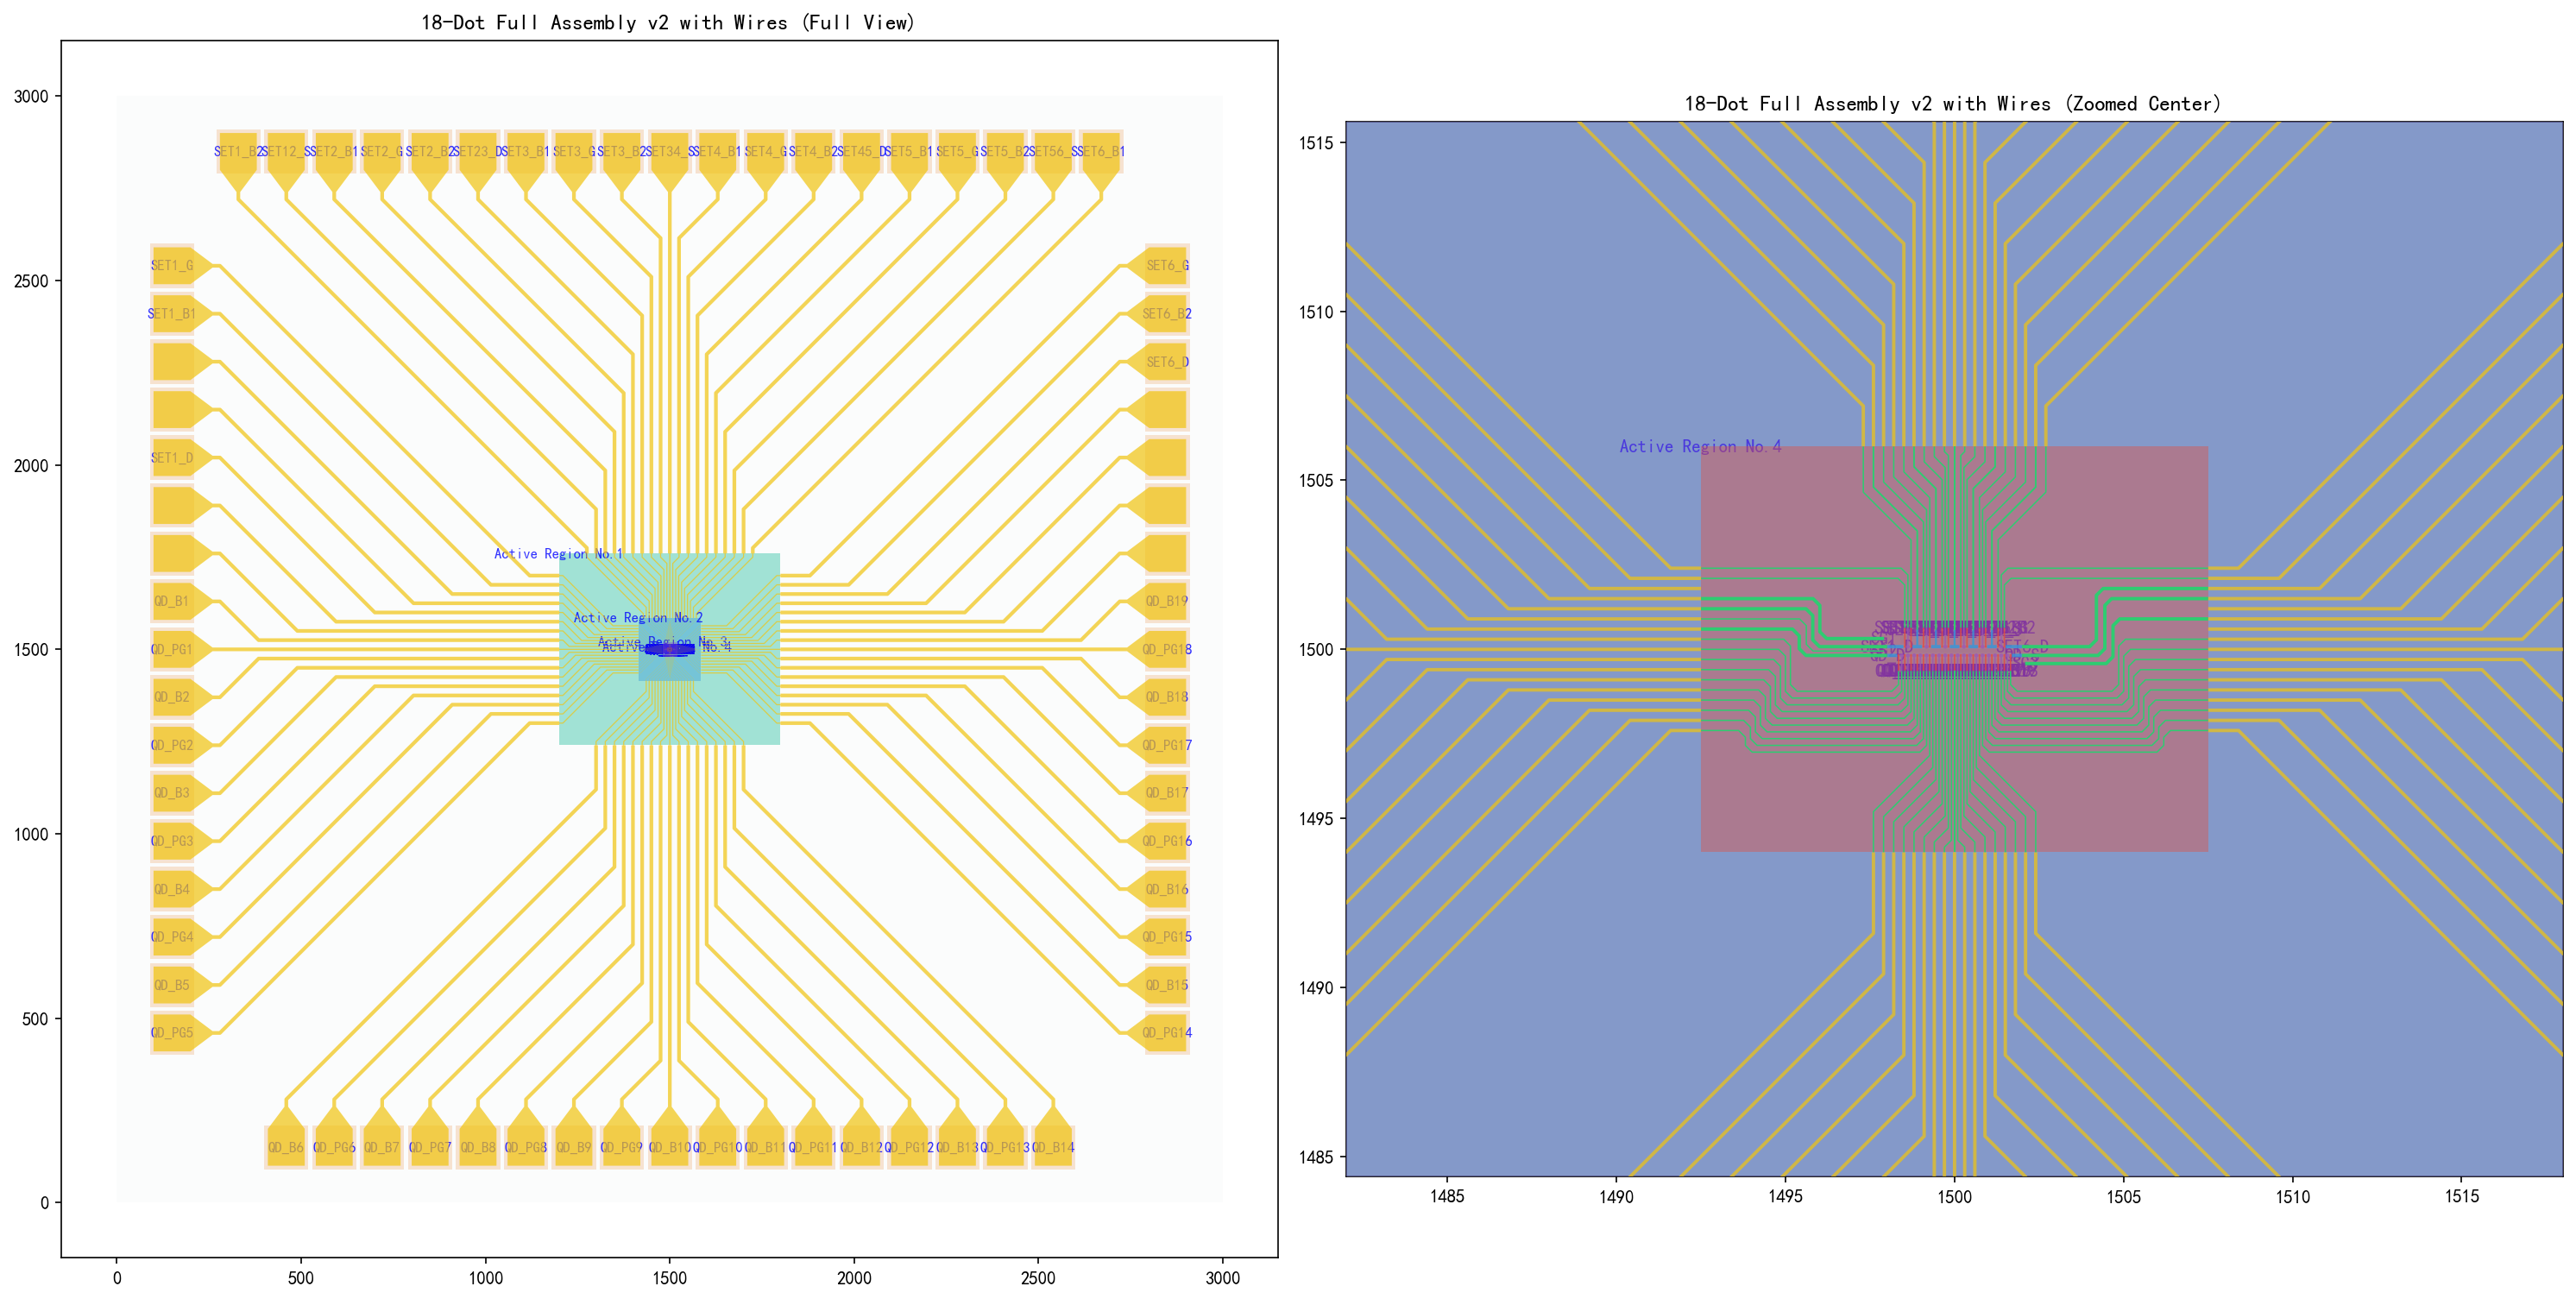


Successfully assembled, wired, and saved 18dot_full_assembly_v2_wired.gds


In [22]:
# 5. Add connection wires one by one (40nm width)
assembly_lib2, assembly_cell2 = generator.assemble_device_and_pad_frame()

if assembly_cell2 is not None:
    import pandas as pd
    from IPython.display import display

    # Calculate translation for device points
    bbox = device_cell.bounding_box()
    dev_cx, dev_cy = (bbox[0][0] + bbox[1][0]) / 2, (bbox[0][1] + bbox[1][1]) / 2
    tx, ty = active_center[0] - dev_cx, active_center[1] - dev_cy

    # 1. Connect Bottom QD leads (QD_B6 ~ QD_B14)
    bottom_labels = ["QD_B6", "QD_PG6", "QD_B7", "QD_PG7", "QD_B8", "QD_PG8", "QD_B9", "QD_PG9", "QD_B10", "QD_PG10", "QD_B11", "QD_PG11", "QD_B12", "QD_PG12", "QD_B13", "QD_PG13", "QD_B14"]
    print("Connecting bottom pad leads...")
    for i, label in enumerate(bottom_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            if label == "QD_B10":
                path_pts = [p_pad, p_dev]
            else:
                dist_from_center = abs(i - 8)
                entry_length = 0.15 * dist_from_center
                delta_x = p_dev[0] - p_pad[0]
                p_turn_pad = (p_pad[0], p_pad[1] + entry_length)
                p_turn_dev = (p_dev[0], p_pad[1] + entry_length + abs(delta_x))
                path_pts = [p_pad, p_turn_pad, p_turn_dev, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040)
            assembly_cell2.add(wire)

    # 2. Connect Right QD leads (QD_PG14 ~ QD_B19)
    QD_right_labels = ["QD_PG14", "QD_B15", "QD_PG15", "QD_B16", "QD_PG16", "QD_B17", "QD_PG17", "QD_B18", "QD_PG18", "QD_B19"]
    print("Connecting right pad leads...")
    for i, label in enumerate(QD_right_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            delta_y = p_pad[1] - p_dev[1]
            dev_entry = 0.4 + 0.2 * abs(9-i)
            bend = 0.2
            extend = 3 + 0.24 * abs(9-i)
            pt1 = (p_dev[0], p_dev[1] - dev_entry)
            pt2 = (p_dev[0] + bend, p_dev[1] - dev_entry - bend)
            pt3 = (p_dev[0] + extend, p_dev[1] - dev_entry - bend)
            pt4 = (p_dev[0] + extend + bend, p_dev[1] - dev_entry)
            pt5 = (p_dev[0] + extend + bend, p_dev[1] + delta_y - bend)
            pt6 = (p_dev[0] + extend + bend * 2, p_dev[1] + delta_y)
            path_pts = [p_pad, pt6, pt5, pt4, pt3, pt2, pt1, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040)
            assembly_cell2.add(wire)

    # 3. Connect Left QD leads (QD_B1 ~ QD_PG5)
    QD_left_labels = ["QD_B1", "QD_PG1", "QD_B2", "QD_PG2", "QD_B3", "QD_PG3", "QD_B4", "QD_PG4", "QD_B5", "QD_PG5"]
    print("Connecting left pad leads...")
    for i, label in enumerate(QD_left_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            delta_y = p_pad[1] - p_dev[1]
            dev_entry = 0.4 + 0.2 * abs(i)
            bend = 0.2
            extend = 3 + 0.24 * abs(i)
            pt1 = (p_dev[0], p_dev[1] - dev_entry)
            pt2 = (p_dev[0] - bend, p_dev[1] - dev_entry - bend)
            pt3 = (p_dev[0] - extend, p_dev[1] - dev_entry - bend)
            pt4 = (p_dev[0] - extend - bend, p_dev[1] - dev_entry)
            pt5 = (p_dev[0] - extend - bend, p_dev[1] + delta_y - bend)
            pt6 = (p_dev[0] - extend - bend * 2, p_dev[1] + delta_y)
            path_pts = [p_pad, pt6, pt5, pt4, pt3, pt2, pt1, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040)
            assembly_cell2.add(wire)

    # left
    label = "SG3"
    print("Connecting SG3 pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        
        delta_x = p_pad[0] - p_dev[0]
        bend = 0.2
        extend = 2.4
            
        pt1 = (p_dev[0] + extend, p_dev[1])
        pt2 = (p_dev[0] + extend + bend, p_dev[1] + bend)
        pt3 = (p_dev[0] + extend + bend, p_pad[1] - bend)
        pt4 = (p_dev[0] + extend + bend*2, p_pad[1])

        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.10)
        assembly_cell2.add(wire)

    label = "QD_S"
    print("Connecting QD_S pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        
        delta_x = p_pad[0] - p_dev[0]
        bend = 0.2
        extend = 2.25
            
        pt1 = (p_dev[0] + extend, p_dev[1])
        pt2 = (p_dev[0] + extend + bend, p_dev[1] + bend)
        pt3 = (p_dev[0] + extend + bend, p_pad[1] - bend)
        pt4 = (p_dev[0] + extend + bend*2, p_pad[1])

        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1)
        assembly_cell2.add(wire)
    
    label = "SET6_D"
    print("Connecting SET6_D pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        
        delta_x = p_pad[0] - p_dev[0]
        bend = 0.2
        extend = 2.0
            
        pt1 = (p_dev[0] + extend, p_dev[1])
        pt2 = (p_dev[0] + extend + bend, p_dev[1] + bend)
        pt3 = (p_dev[0] + extend + bend, p_pad[1] - bend)
        pt4 = (p_dev[0] + extend + bend*2, p_pad[1])

        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1)
        assembly_cell2.add(wire)

    SET_left_labels = ["SET1_B1", "SET1_G"]
    print("Connecting left pad leads...")
    for i, label in enumerate(SET_left_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            delta_y = p_pad[1] - p_dev[1]

            bend = 0.2
            pt1 = (p_dev[0], p_pad[1] - bend)
            pt2 = (p_dev[0] - bend, p_pad[1] )
            
            path_pts = [p_pad, pt2, pt1, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040)
            assembly_cell2.add(wire)

    # right

    SET_right_labels = ["SET6_B2", "SET6_G"]
    for i, label in enumerate(SET_right_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            delta_y = p_pad[1] - p_dev[1]

            bend = 0.2
            pt1 = (p_dev[0], p_pad[1] - bend)
            pt2 = (p_dev[0] + bend, p_pad[1] )
            
            path_pts = [p_pad, pt2, pt1, p_dev]
            wire = generator.create_gds_wire(path_pts, width=0.040)
            assembly_cell2.add(wire)

    label = "QD_D"
    print("Connecting QD_D pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        
        delta_x = p_pad[0] - p_dev[0]
        bend = 0.2
        extend = 2.4
            
        pt1 = (p_dev[0] - extend, p_dev[1])
        pt2 = (p_dev[0] - extend - bend, p_dev[1] + bend)
        pt3 = (p_dev[0] - extend - bend, p_pad[1] - bend)
        pt4 = (p_dev[0] - extend - bend*2, p_pad[1])

        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1)
        assembly_cell2.add(wire)

    label = "SG2"
    print("Connecting SG2 pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        
        delta_x = p_pad[0] - p_dev[0]
        bend = 0.2
        extend = 2.1
            
        pt1 = (p_dev[0] - extend, p_dev[1])
        pt2 = (p_dev[0] - extend - bend, p_dev[1] + bend)
        pt3 = (p_dev[0] - extend - bend, p_pad[1] - bend)
        pt4 = (p_dev[0] - extend - bend*2, p_pad[1])

        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.04)
        assembly_cell2.add(wire)

    label = "SET1_D"
    print("Connecting SET1_D pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        
        delta_x = p_pad[0] - p_dev[0]
        bend = 0.2
        extend = 2.0
            
        pt1 = (p_dev[0] - extend, p_dev[1])
        pt2 = (p_dev[0] - extend - bend, p_dev[1] + bend)
        pt3 = (p_dev[0] - extend - bend, p_pad[1] - bend)
        pt4 = (p_dev[0] - extend - bend*2, p_pad[1])

        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1)
        assembly_cell2.add(wire)

    label = "SG1"
    print("Connecting SG1 pad lead...")
    if label in device_connection_points and label in pad_connection_points:
        p_pad = pad_connection_points[label]
        p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
        
        delta_x = p_pad[0] - p_dev[0]
        bend = 0.2
        extend = 1.7
            
        pt1 = (p_dev[0] - extend, p_dev[1])
        pt2 = (p_dev[0] - extend - bend, p_dev[1] + bend)
        pt3 = (p_dev[0] - extend - bend, p_pad[1] - bend)
        pt4 = (p_dev[0] - extend - bend*2, p_pad[1])

        path_pts = [p_pad, pt4, pt3, pt2, pt1, p_dev]
        wire = generator.create_gds_wire(path_pts, width=0.1)
        assembly_cell2.add(wire)

    # top
    # label = "SET34_S"
    # print("Connecting SET34_S pad lead...")
    # if label in device_connection_points and label in pad_connection_points:
    #     p_pad = pad_connection_points[label]
    #     p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)

    #     path_pts = [p_pad, p_dev]
    #     wire = generator.create_gds_wire(path_pts, width=0.1)
    #     assembly_cell2.add(wire)

    top_labels = ["SET1_B2", "SET12_S", "SET2_B1", "SET2_G", "SET2_B2", "SET23_D", "SET3_B1", "SET3_G", "SET3_B2", 
                  "SET34_S", 
                  "SET4_B1", "SET4_G", "SET4_B2", "SET45_D", "SET5_B1", "SET5_G", "SET5_B2", "SET56_S", "SET6_B1"]
    print("Connecting top pad leads...")
    for i, label in enumerate(top_labels):
        if label in device_connection_points and label in pad_connection_points:
            p_pad = pad_connection_points[label]
            p_dev = (device_connection_points[label][0] + tx, device_connection_points[label][1] + ty)
            if label == "SET34_S":
                path_pts = [p_pad, p_dev]
            else:
                dist_from_center = abs(i - 9)
                entry_length = 0.15 * dist_from_center
                delta_x = p_dev[0] - p_pad[0]
                p_turn_pad = (p_pad[0], p_pad[1] - entry_length)
                p_turn_dev = (p_dev[0], p_pad[1] - entry_length - abs(delta_x))
                path_pts = [p_pad, p_turn_pad, p_turn_dev, p_dev]
            width = 0.050 if "_S" in label or "_D" in label else 0.040
            wire = generator.create_gds_wire(path_pts, width=width)
            assembly_cell2.add(wire)


    # 7. Visualize and save the final assembly
    generator.visualize_and_save_assembly(assembly_lib2, assembly_cell2, "18-Dot Full Assembly v2 with Wires", "18dot_full_assembly_v2_wired.gds", zoom_factor=0.03)
    print("\nSuccessfully assembled, wired, and saved 18dot_full_assembly_v2_wired.gds")
else:
    print("Error: Assembly failed.")